In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/df_with_2regimes.csv')

# take log of realized variance
df['log_realized_variance'] = np.log(df['realized_variance'])
# lag 1,2 andd 3 of log realized variance
df['rv_lag1'] = df['log_realized_variance'].shift(1)
df['rv_lag2'] = df['log_realized_variance'].shift(2)
df['rv_lag3'] = df['log_realized_variance'].shift(3)

# rolling mean of log realized variance over the past 30 days
df['rv_rolling_mean_30'] = df['log_realized_variance'].rolling(window=30).mean() 

# drop rows with NaN values (due to lag and rolling mean)
df = df.dropna().reset_index(drop=True)
df.head(30)
df.info()
# start from 2017-07-13
df = df[df['date'] >= '2017-07-13'].reset_index(drop=True)
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489 entries, 0 to 3488
Data columns (total 42 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        3489 non-null   object 
 1   log_return                                  3489 non-null   float64
 2   realized_variance                           3489 non-null   float64
 3   realized_volatility                         3489 non-null   float64
 4   gtrend_pct_change                           3489 non-null   float64
 5   blockchain_diff_log_n_transactions          3489 non-null   float64
 6   blockchain_diff_log_transaction_fee_usd     3489 non-null   float64
 7   blockchain_diff_log_n_unique_addresses      3489 non-null   float64
 8   blockchain_diff_log_transaction_volume_usd  3489 non-null   float64
 9   log_volume                                  3489 non-null   float64
 10  target      

In [3]:
svr_features = ["log_return", "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg", 
    "rv_lag1", "rv_lag2", "rv_lag3", "rv_rolling_mean_30"]

len(svr_features)

32

In [4]:
# split data into train, evaluation and out of sample test sets 60/25/15
n= len(df)

train_size = int(n * 0.6)
eval_size = int(n * 0.25)

train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_size 
eval_end_idx = eval_start_idx + eval_size

test_start_idx = eval_end_idx
test_end_idx = n

train_df = df.iloc[train_start_idx:train_end_idx].copy()
eval_df = df.iloc[eval_start_idx:eval_end_idx].copy()
test_df = df.iloc[test_start_idx:test_end_idx].copy()

print(f"Train set: {len(train_df)} rows")
print(f"Evaluation set: {len(eval_df)} rows")
print(f"Test set: {len(test_df)} rows")

Train set: 1875 rows
Evaluation set: 781 rows
Test set: 469 rows


In [5]:
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler

In [6]:
def one_step_svr_forecast(fitted_svr, x_next):
    
    if fitted_svr is None:
        return np.nan

    try:
        x_next = np.asarray(x_next).reshape(1, -1)
        pred = fitted_svr.predict(x_next)[0]
        return float(pred)
    except Exception:
        return np.nan

    
def fit_svr_safe(X_train, y_train, C=1.0, epsilon=1e-4, min_obs=100):
    if len(X_train) < min_obs:
        return None

    try:
        model = LinearSVR(C=C, epsilon=epsilon, dual=True, max_iter=20000)
        model.fit(X_train, y_train)
        return model
    except Exception as e:
        print("LinearSVR fit failed:", e)
        return None

In [7]:
def rolling_svr_linear_eval(
    df_full,
    start_idx,
    end_idx,
    x_feature_cols,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    scale_window=365,
    C=1.0,
    epsilon=1e-4,
    min_obs=200
):
    results = []

    df = df_full.copy()

    # target is next day's realized variance
    df["target_lead1"] = df[realized_var_col].shift(-1)

    feature_cols = x_feature_cols

    for t in range(start_idx - 1, end_idx - 1):
        current_row = df.iloc[t]
        next_row = df.iloc[t + 1]

        current_date = current_row[date_col]
        next_date = next_row[date_col]

        # training rows exclude row t
        window_df = df.iloc[max(0, t - rolling_window + 1): t].copy()

        needed_cols = feature_cols + ["target_lead1"]
        train_df = window_df[needed_cols].dropna()

        if len(train_df) < min_obs:
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_target": next_row[realized_var_col],
                "pred_target": np.nan
            })
            continue
        
        # scale features using past data up to t, excluding t
        scaler_hist = window_df[feature_cols].dropna().iloc[-min(scale_window, len(window_df[feature_cols].dropna())):].copy()

        if len(scaler_hist) == 0:
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_target": next_row[realized_var_col],
                "pred_target": np.nan
            })
            continue

        scaler = StandardScaler()
        scaler.fit(scaler_hist)

        # scale training features
        X_train = scaler.transform(train_df[feature_cols])
        y_train = train_df["target_lead1"].values

        model = fit_svr_safe(
            X_train=X_train,
            y_train=y_train,
            C=C,
            epsilon=epsilon,
            min_obs=min_obs
        )

        x_t = current_row[feature_cols]

        if x_t.isna().any():
            pred = np.nan
        else:
            x_t_df = x_t.to_frame().T
            x_t_scaled = scaler.transform(x_t_df)
            pred = one_step_svr_forecast(model, x_t_scaled[0])

        results.append({
            "date": next_date,
            "forecast_origin_date": current_date,
            "actual_target": next_row[realized_var_col],
            "pred_target": pred
        })

    return pd.DataFrame(results)

In [8]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike 


In [9]:
from itertools import product  

In [10]:
svr_grid = {
    "kernel": ["linear"],
    "C": [0.1, 1.0, 10.0],
    "epsilon": [1e-4, 1e-3, 1e-2]
}

svr_param_grid = []
for kernel, C, epsilon in product(
    svr_grid["kernel"],
    svr_grid["C"],
    svr_grid["epsilon"]
):
    svr_param_grid.append({
        "kernel": kernel,
        "C": C,
        "epsilon": epsilon
    })
print(f"Total SVR configs: {len(svr_param_grid)}")

Total SVR configs: 9


In [11]:
svr_results = []

for i, params in enumerate(svr_param_grid, 1):
    kernel = params["kernel"]
    C = params["C"]
    epsilon = params["epsilon"]

    print(f"\n[{i}/{len(svr_param_grid)}] Testing SVR: {params}")

    try:
        eval_svr = rolling_svr_linear_eval(
            df_full=df,
            start_idx=eval_start_idx,
            end_idx=eval_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=365,
            C=C,
            epsilon=epsilon,
            min_obs=100
        )

        # convert log variance back to variance for QLIKE
        eval_svr["actual_var"] = np.exp(eval_svr["actual_target"])
        eval_svr["pred_var"]   = np.exp(eval_svr["pred_target"])

        eval_rmse = rmse(eval_svr["actual_target"], eval_svr["pred_target"])
        eval_qlike = qlike(eval_svr["actual_var"], eval_svr["pred_var"])
        n_eval_forecasts = eval_svr["pred_target"].notna().sum()

        svr_results.append({
            **params,
            "eval_rmse": eval_rmse,
            "eval_qlike": eval_qlike,
            "n_eval_forecasts": n_eval_forecasts
        })

    except Exception as e:
        svr_results.append({
            **params,
            "eval_rmse": np.nan,
            "eval_qlike": np.nan,
            "n_eval_forecasts": 0,
            "error": str(e)
        })

svr_results_df = pd.DataFrame(svr_results).sort_values("eval_qlike")
print(svr_results_df.head())


[1/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001}

[2/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001}

[3/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.01}

[4/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.0001}

[5/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.001}

[6/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.01}

[7/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.0001}


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increas


[8/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.001}


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increas


[9/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.01}


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increas

   kernel    C  epsilon  eval_rmse  eval_qlike  n_eval_forecasts
1  linear  0.1   0.0010   1.116859    0.606033               781
0  linear  0.1   0.0001   1.116841    0.606160               781
2  linear  0.1   0.0100   1.116593    0.606797               781
5  linear  1.0   0.0100   1.103382    0.744946               781
4  linear  1.0   0.0010   1.104532    0.750144               781


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [12]:
svr_results_df = pd.DataFrame(svr_results).sort_values("eval_qlike")
print(svr_results_df.head())

   kernel    C  epsilon  eval_rmse  eval_qlike  n_eval_forecasts
1  linear  0.1   0.0010   1.116859    0.606033               781
0  linear  0.1   0.0001   1.116841    0.606160               781
2  linear  0.1   0.0100   1.116593    0.606797               781
5  linear  1.0   0.0100   1.103382    0.744946               781
4  linear  1.0   0.0010   1.104532    0.750144               781


In [13]:
best_svr_params = svr_results_df.iloc[0].to_dict()
print(best_svr_params)

{'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001, 'eval_rmse': 1.1168592057897837, 'eval_qlike': 0.60603336704811, 'n_eval_forecasts': 781}


In [14]:
test_regime_start_idx = max(0, test_start_idx - 365)

test_svr = rolling_svr_linear_eval(
    df_full=df,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=best_svr_params["C"],
    epsilon=best_svr_params["epsilon"],
    min_obs=100
)


test_rmse = rmse(test_svr["actual_target"], test_svr["pred_target"])


# Convert back to variance scale for QLIKE
test_svr["actual_var"] = np.maximum(np.exp(test_svr["actual_target"]), 1e-12)
test_svr["pred_var"]   = np.maximum(np.exp(test_svr["pred_target"]), 1e-12)

test_qlike = qlike(test_svr["actual_var"], test_svr["pred_var"])
test_rsme_variance = rmse(test_svr["actual_var"], test_svr["pred_var"])

print("Final Test RMSE :", test_rmse)
print("Final Test RMSE (var scale):", test_rsme_variance)
print("Final Test QLIKE:", test_qlike)
print("Number of test forecasts:", test_svr["pred_target"].notna().sum())



Final Test RMSE : 1.0559038012657223
Final Test RMSE (var scale): 0.0006559127349776623
Final Test QLIKE: 0.45253174412712216
Number of test forecasts: 469


In [17]:
test_svr.head()

,date,forecast_origin_date,actual_target,pred_target,actual_var,pred_var
0,2024-10-20,2024-10-19,-9.314845,-8.260595,0.000090,0.000259
1,2024-10-21,2024-10-20,-7.873473,-7.789070,0.000381,0.000414
2,2024-10-22,2024-10-21,-8.046507,-7.589355,0.000320,0.000506
3,2024-10-23,2024-10-22,-8.161787,-7.572213,0.000285,0.000515
4,2024-10-24,2024-10-23,-7.997675,-7.567514,0.000336,0.000517


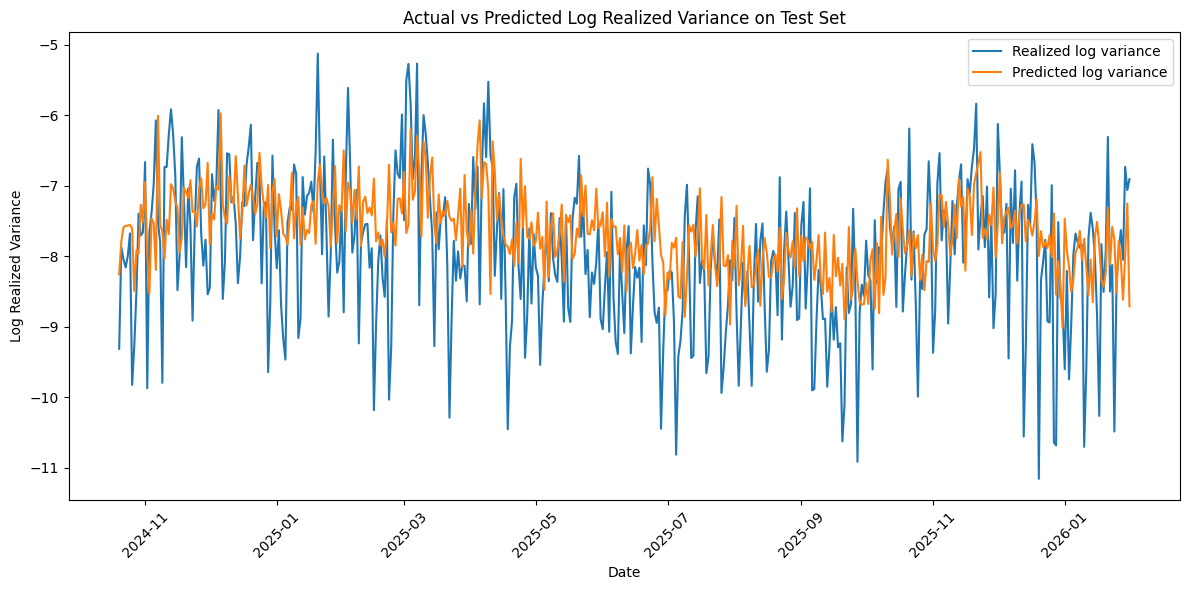

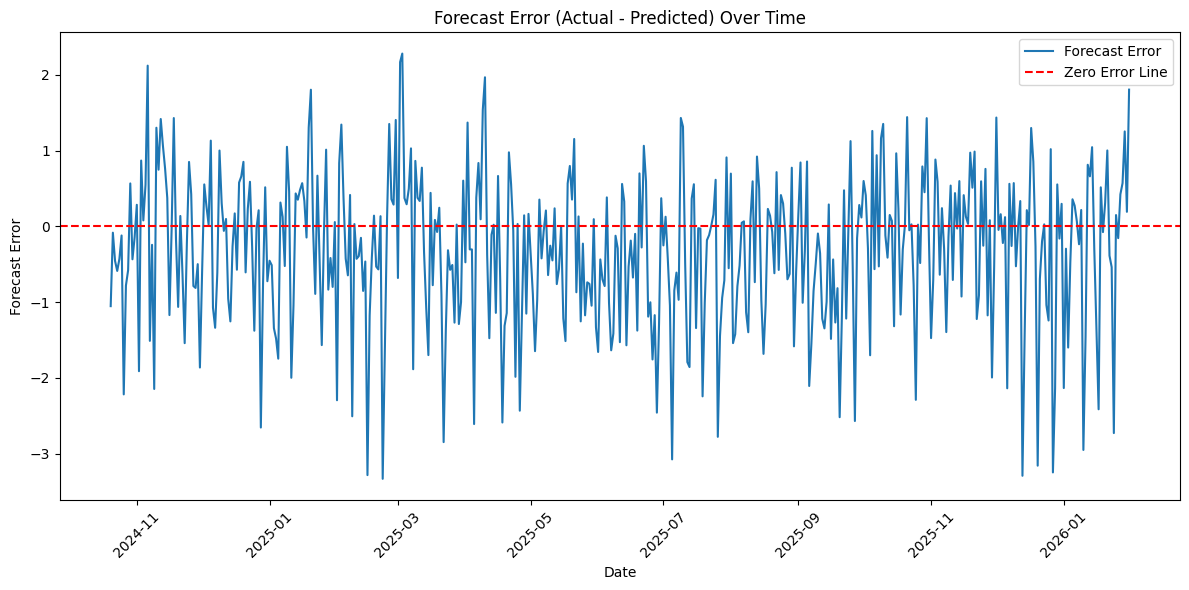

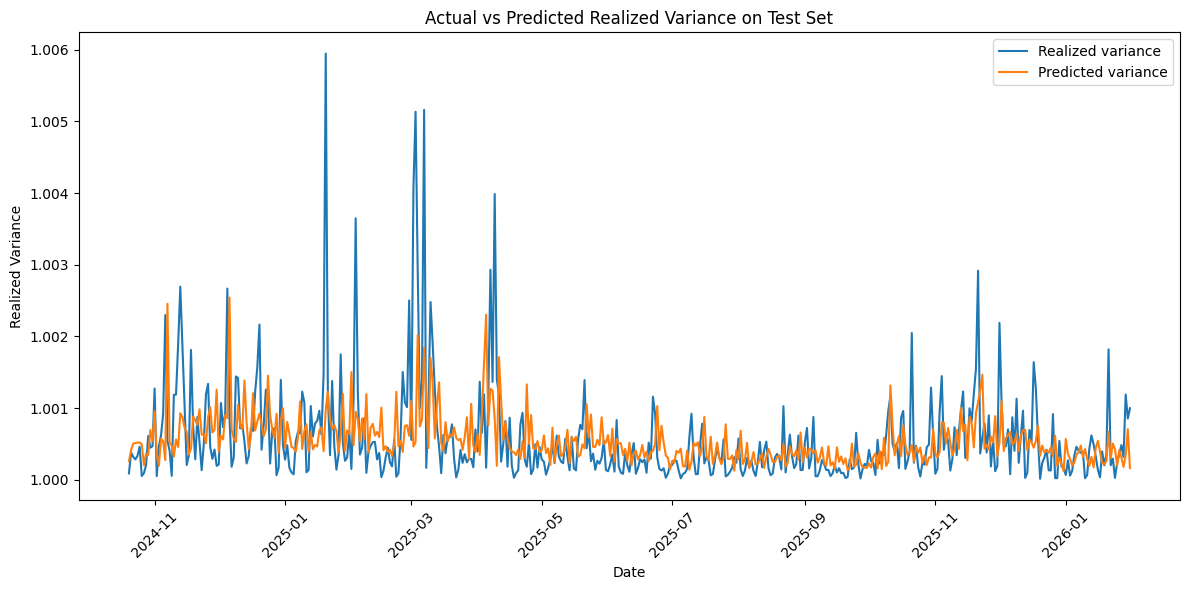

In [18]:
# plot actual vs predicted log variance on test set
import matplotlib.pyplot as plt
test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["actual_target"], label="Realized log variance")
plt.plot(test_svr["date"], test_svr["pred_target"], label="Predicted log variance")
plt.title("Actual vs Predicted Log Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Log Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot errors over time
test_svr['date'] = pd.to_datetime(test_svr['date'])
test_svr['error'] = test_svr["actual_target"] - test_svr["pred_target"]
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["error"], label="Forecast Error") 
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Forecast Error (Actual - Predicted) Over Time")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], np.exp(test_svr["actual_var"]), label="Realized variance")
plt.plot(test_svr["date"], np.exp(test_svr["pred_var"]), label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [21]:
# export results to csv
#test_svr.to_csv("results/svr_test_results.csv", index=False)